In [1]:
!apt-get -qq update
!apt-get -qq install -y tesseract-ocr tesseract-ocr-spa
!pip -q install pytesseract opencv-python-headless pillow

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package tesseract-ocr-spa.
(Reading database ... 122815 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-spa_1%3a4.1.0-2_all.deb ...
Unpacking tesseract-ocr-spa (1:4.1.0-2) ...
Setting up tesseract-ocr-spa (1:4.1.0-2) ...


In [4]:
!apt-get -qq install -y fonts-dejavu-core

Selecting previously unselected package fonts-dejavu-mono.
(Reading database ... 122819 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-mono_2.37-8_all.deb ...
Unpacking fonts-dejavu-mono (2.37-8) ...
Selecting previously unselected package fonts-dejavu-core.
Preparing to unpack .../fonts-dejavu-core_2.37-8_all.deb ...
Unpacking fonts-dejavu-core (2.37-8) ...
Setting up fonts-dejavu-mono (2.37-8) ...
Setting up fonts-dejavu-core (2.37-8) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


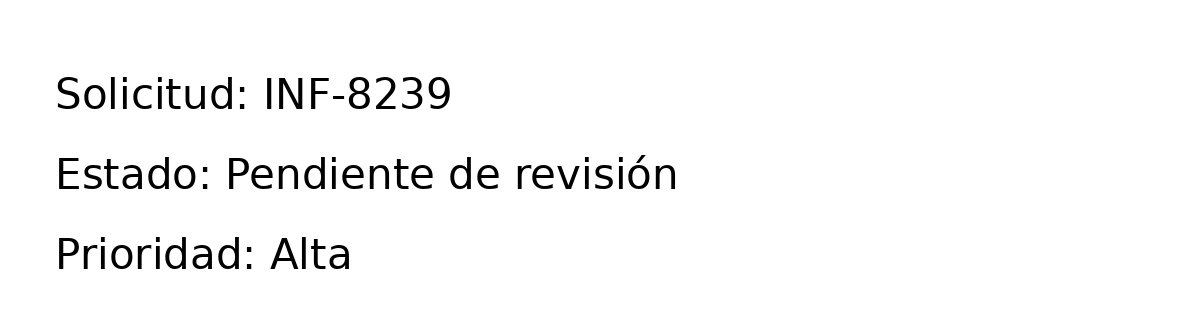

In [5]:
from PIL import Image, ImageDraw, ImageFont

canvas = Image.new("RGB", (1200, 320), "white")
draw = ImageDraw.Draw(canvas)

font = ImageFont.truetype(
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    42
)

draw.text((55, 70), "Solicitud: INF-8239", fill="black", font=font)
draw.text((55, 150), "Estado: Pendiente de revisión", fill="black", font=font)
draw.text((55, 230), "Prioridad: Alta", fill="black", font=font)

display(canvas)
canvas.save("documento_demo.png")

In [6]:
import cv2
import pytesseract
from PIL import Image

image = cv2.imread("documento_demo.png")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

text = pytesseract.image_to_string(
    binary,
    lang="spa"
)

print(text)

Solicitud: INF-8239
Estado: Pendiente de revisión
Prioridad: Alta



In [7]:
data = pytesseract.image_to_data(
    binary,
    lang="spa",
    output_type=pytesseract.Output.DATAFRAME
)

words = data.dropna(subset=["text"])
words = words[words["text"].str.strip().ne("")]

words[["text", "conf"]].reset_index(drop=True)

,text,conf
0,Solicitud:,93.242203
1,INF-8239,90.223457
2,Estado:,96.500381
3,Pendiente,96.744858
4,de,96.914627
5,revisión,96.785057
6,Prioridad:,95.532761
7,Alta,95.671257


## Interpretación responsable

El sistema OCR logró reconocer correctamente el contenido de la imagen de demostración y presentó valores de confianza elevados para todas las palabras identificadas.

Sin embargo, una confianza alta no garantiza que el contenido reconocido sea verdadero ni que el documento haya sido interpretado correctamente en su contexto. OCR únicamente transforma información visual en texto procesable.

En documentos reales, especialmente cuando contienen nombres, códigos, montos, fechas o información sensible, la salida debe ser validada antes de utilizarse en procesos posteriores.

La calidad del reconocimiento puede verse afectada por factores como resolución, iluminación, inclinación, ruido, tipografía, idioma y estructura del documento.

Este microejemplo muestra cómo una imagen puede convertirse en texto y posteriormente alimentar tareas de minería, clasificación o tamizaje, pero cada etapa puede introducir errores que deben medirse y revisarse.